In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
# esm_file= os.path.join(run_dir, 'cm3-demo-datastore/cm3-virtual-datastore.json')
plotfolder='/g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json
Plot folder path:  /g/data/tm70/ek4684/access-om3-paper-1/notebooks/mkfigs_output4/


In [3]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import dask.array as da

In [4]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


2025-11-05 16:08:15,242 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:44783' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 33), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 271), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 335), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 454), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 280), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 399), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 344), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 289), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 527), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 472), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 591), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 417), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 536), ('sum-aggregate-fd4149d3f7d2a770b96755de4c91b51a', 362), ('sum-aggrega

In [5]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [6]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
# datastore_filtered = datastore.search(realm="ocean", frequency="1mon")

# for col in COLUMNS_WITH_ITERABLES:
#     datastore_filtered.df[col] = datastore_filtered.df[col].astype("object").map(lambda x: list(map(str, x)))

# df = available_variables(datastore_filtered)

# Load ocean and atmosphere areas

In [7]:
wet = datastore.search(variable="wet").to_dask().compute()
areacello = datastore.search(variable="areacello").to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

In [8]:
EARTH_RADIUS = 6371229.0
nlon, nlat = 192, 144
dx = 360 / nlon
dy = 180 / nlat

element_lat = (np.arange(nlat) + 0.5) * dy  - 90
element_lat = element_lat[:, None] * np.ones(nlon)[None, :]
element_lon = (np.arange(nlon) + 0.5) * dx

pi_over_180 = np.pi / 180
element_areas = dx * pi_over_180 * (
  np.sin((element_lat + 0.5 * dy) * pi_over_180) - np.sin((element_lat - 0.5 * dy) * pi_over_180)
)

areacella = element_areas * EARTH_RADIUS**2
areacella = xr.DataArray(areacella, coords=dict(lat=element_lat[:, 0], lon=element_lon), dims=('lat', 'lon'))

total_ocn_fraction = areacello.sum().data / areacella.sum().data

# Ocean time series

## Ocean heatflux

## Load CM3 data

In [11]:
cm3_ocean_heatflux = datastore.search(variable="net_heat_coupler", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).net_heat_coupler

In [12]:
# area weighted average of ocean heatflux
# average over entire earth for comparison with TOA
cm3_avg_ocean_heatflux = cm3_ocean_heatflux.weighted(areacello.fillna(0)).mean(dim=('yh', 'xh')).compute() * total_ocn_fraction

### Load CM2 data

In [9]:
def load_cm2_data(var_name, year_start, year_end):

    da_list = []

    for year in range(year_start, year_end):
        for month in [1, 7]:
            
            fn = f'ocean-2d-{var_name}-1-monthly-mean-ym_{str(year).zfill(4)}_0{month}.nc'
            fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/{fn}'
            da_list.append(xr.open_dataset(fp, drop_variables=["average_T1", "average_T2"], chunks="auto")[var_name])

    return xr.concat(da_list, dim='time')


cm2_heatflux = load_cm2_data('sfc_hflux_coupler', 1, 51).rename(yt_ocean="yh", xt_ocean="xh")

In [10]:
fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/ocean-2d-area_t.nc'
cm2_area = xr.open_dataset(fp).area_t.data
cm2_area = xr.DataArray(cm2_area, coords=dict(yh=cm2_heatflux.yh, xh=cm2_heatflux.xh), dims=('yh', 'xh'))

In [15]:
cm2_avg_ocean_heatflux = cm2_heatflux.weighted(cm2_area.fillna(0)).mean(dim=('yh', 'xh')).compute() * total_ocn_fraction

### Plot

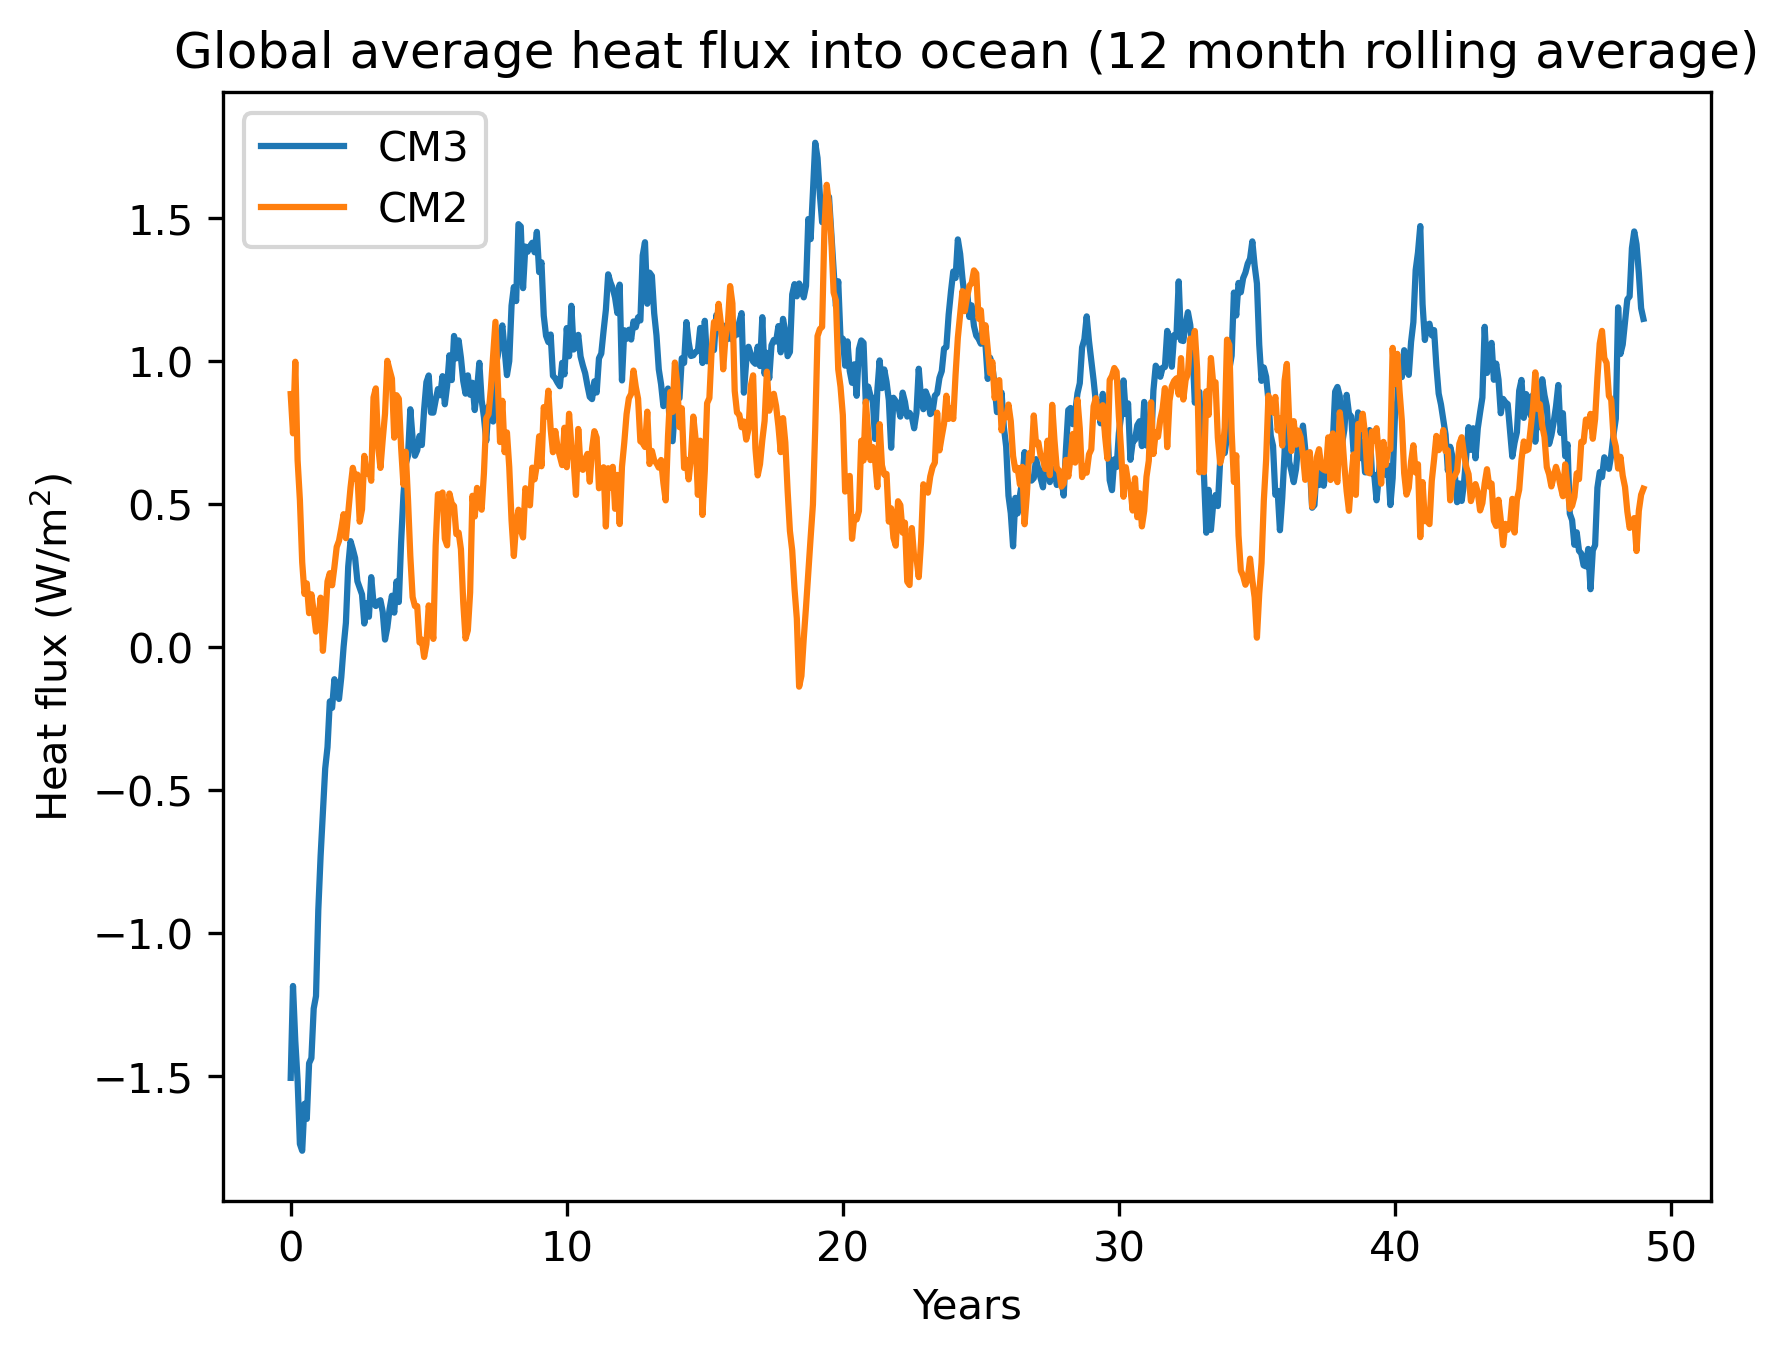

In [16]:
N = 12
rolling_avg = np.convolve(cm3_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label="CM3")

rolling_avg = np.convolve(cm2_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label="CM2")

plt.title('Global average heat flux into ocean (12 month rolling average)')
plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')
plt.legend()

## SST

In [17]:
cm3_sst = datastore.search(variable="tos", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).tos

In [18]:
# area weighted average of SST
cm3_avg_sst = cm3_sst.weighted(areacello.fillna(0)).mean(dim=('yh', 'xh')).compute()

In [19]:
year_start = 1
year_end = 51
da_list = []

for year in range(year_start, year_end):
    for month in [1, 7]:
        
        fn = f'ocean-scalar-1-daily-ym_{str(year).zfill(4)}_0{month}.nc'
        da_list.append(xr.open_dataset(f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ocn/{fn}')['temp_surface_ave'])

cm2_avg_sst = xr.concat(da_list, dim='time').data[:, 0]

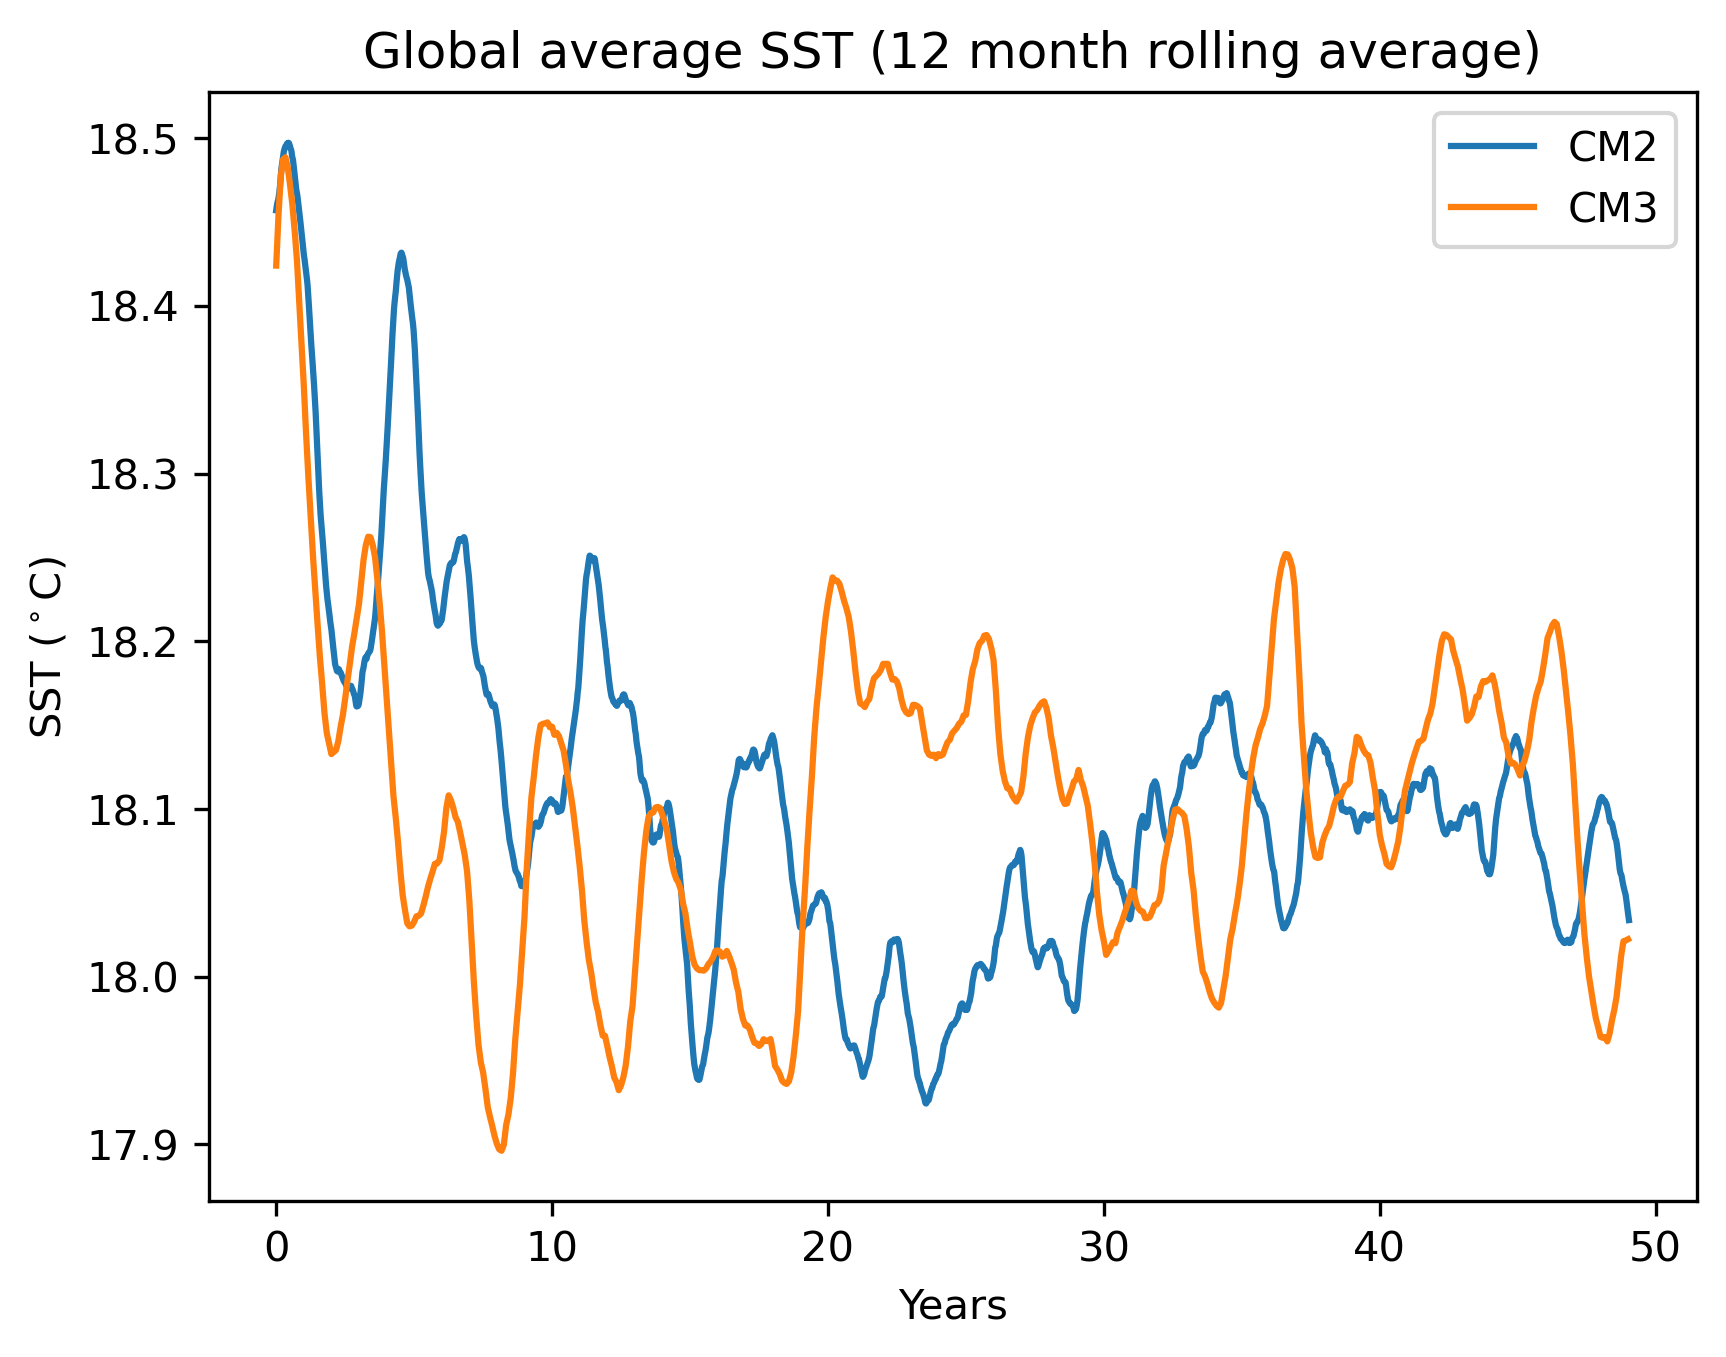

In [21]:
N = 365
avg_flx = np.convolve(cm2_avg_sst, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(avg_flx)) / N, avg_flx, label='CM2')

N = 12
avg_flx = np.convolve(cm3_avg_sst, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(avg_flx)) / 12, avg_flx, label='CM3')

plt.title('Global average SST (12 month rolling average)')

plt.xlabel('Years')
plt.ylabel('SST ($^\circ$C)')
plt.legend()

# Ice time series

## Ice area

### Load CM3 data

In [30]:
fn = "seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json"
fp = os.path.join(os.path.split(esm_file)[0], 'virtualised_outputs', fn)
cm3_ice_ds = xr.open_dataset(fp, engine="kerchunk")

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


In [32]:
cm3_sh_mask = areacello.data.copy()
cm3_sh_mask[cm3_sh_mask.data.shape[0]//2:] = 0
cm3_sh_mask = xr.DataArray(cm3_sh_mask, dims=('nj', 'ni')).fillna(0)

cm3_nh_mask = areacello.data.copy()
cm3_nh_mask[:cm3_nh_mask.data.shape[0]//2] = 0
cm3_nh_mask = xr.DataArray(cm3_nh_mask, dims=('nj', 'ni')).fillna(0)

In [39]:
%%time
cm3_nh_ice_area = cm3_ice_ds.aice_m.weighted(cm3_nh_mask).sum(dim=('nj', 'ni')).compute()
cm3_sh_ice_area = cm3_ice_ds.aice_m.weighted(cm3_sh_mask).sum(dim=('nj', 'ni')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/seaIce.1mon.nbnd:2.nc:5.ni:1440.nj:1142.nkaer:5.nkbio:3.nkice:4.nksnow:1.json


CPU times: user 7.68 s, sys: 777 ms, total: 8.46 s
Wall time: 1min 25s


### Load CM2 data

In [11]:
cm2_sh_mask = cm2_area.data.copy()
cm2_sh_mask[cm2_sh_mask.data.shape[0]//2:] = 0
cm2_sh_mask = xr.DataArray(cm2_sh_mask, dims=('nj', 'ni')).fillna(0)

cm2_nh_mask = cm2_area.data.copy()
cm2_nh_mask[:cm2_nh_mask.data.shape[0]//2] = 0
cm2_nh_mask = xr.DataArray(cm2_nh_mask, dims=('nj', 'ni')).fillna(0)

In [12]:
year = month = 1
fn = f'iceh_m.{str(year).zfill(4)}-{str(month).zfill(2)}.nc'
fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ice/{fn}'

all_vars = xr.open_dataset(fp).data_vars.keys()

keep_vars = ["aice", "vicen"]
drop_vars = [var for var in all_vars if not var in keep_vars]

In [23]:
%%time
cm2_cice_ds_list = []
year_start = 1
year_end = 50
for year in range(year_start, year_end+1):
    for month in range(1, 13):
        fn = f'iceh_m.{str(year).zfill(4)}-{str(month).zfill(2)}.nc'
        fp = f'/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/ice/{fn}'
        cm2_cice_ds_list.append(xr.open_dataset(fp, drop_variables=drop_vars, chunks=dict(time=1, nc=1, nj=-1, ni=-1)))

CPU times: user 56.5 s, sys: 3.66 s, total: 1min
Wall time: 1min 1s


In [14]:
cm2_aice = xr.DataArray(da.concatenate([ds.aice.data for ds in cm2_cice_ds_list]), dims=('time', 'nj', 'ni'))

In [15]:
%%time
cm2_nh_ice_area = cm2_aice.weighted(cm2_nh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 119 ms, sys: 28.1 ms, total: 147 ms
Wall time: 828 ms


In [35]:
%%time
cm2_sh_ice_area = cm2_aice.weighted(cm2_sh_mask).sum(dim=('nj', 'ni')).compute()

CPU times: user 4.3 s, sys: 349 ms, total: 4.65 s
Wall time: 41.1 s


### Plot

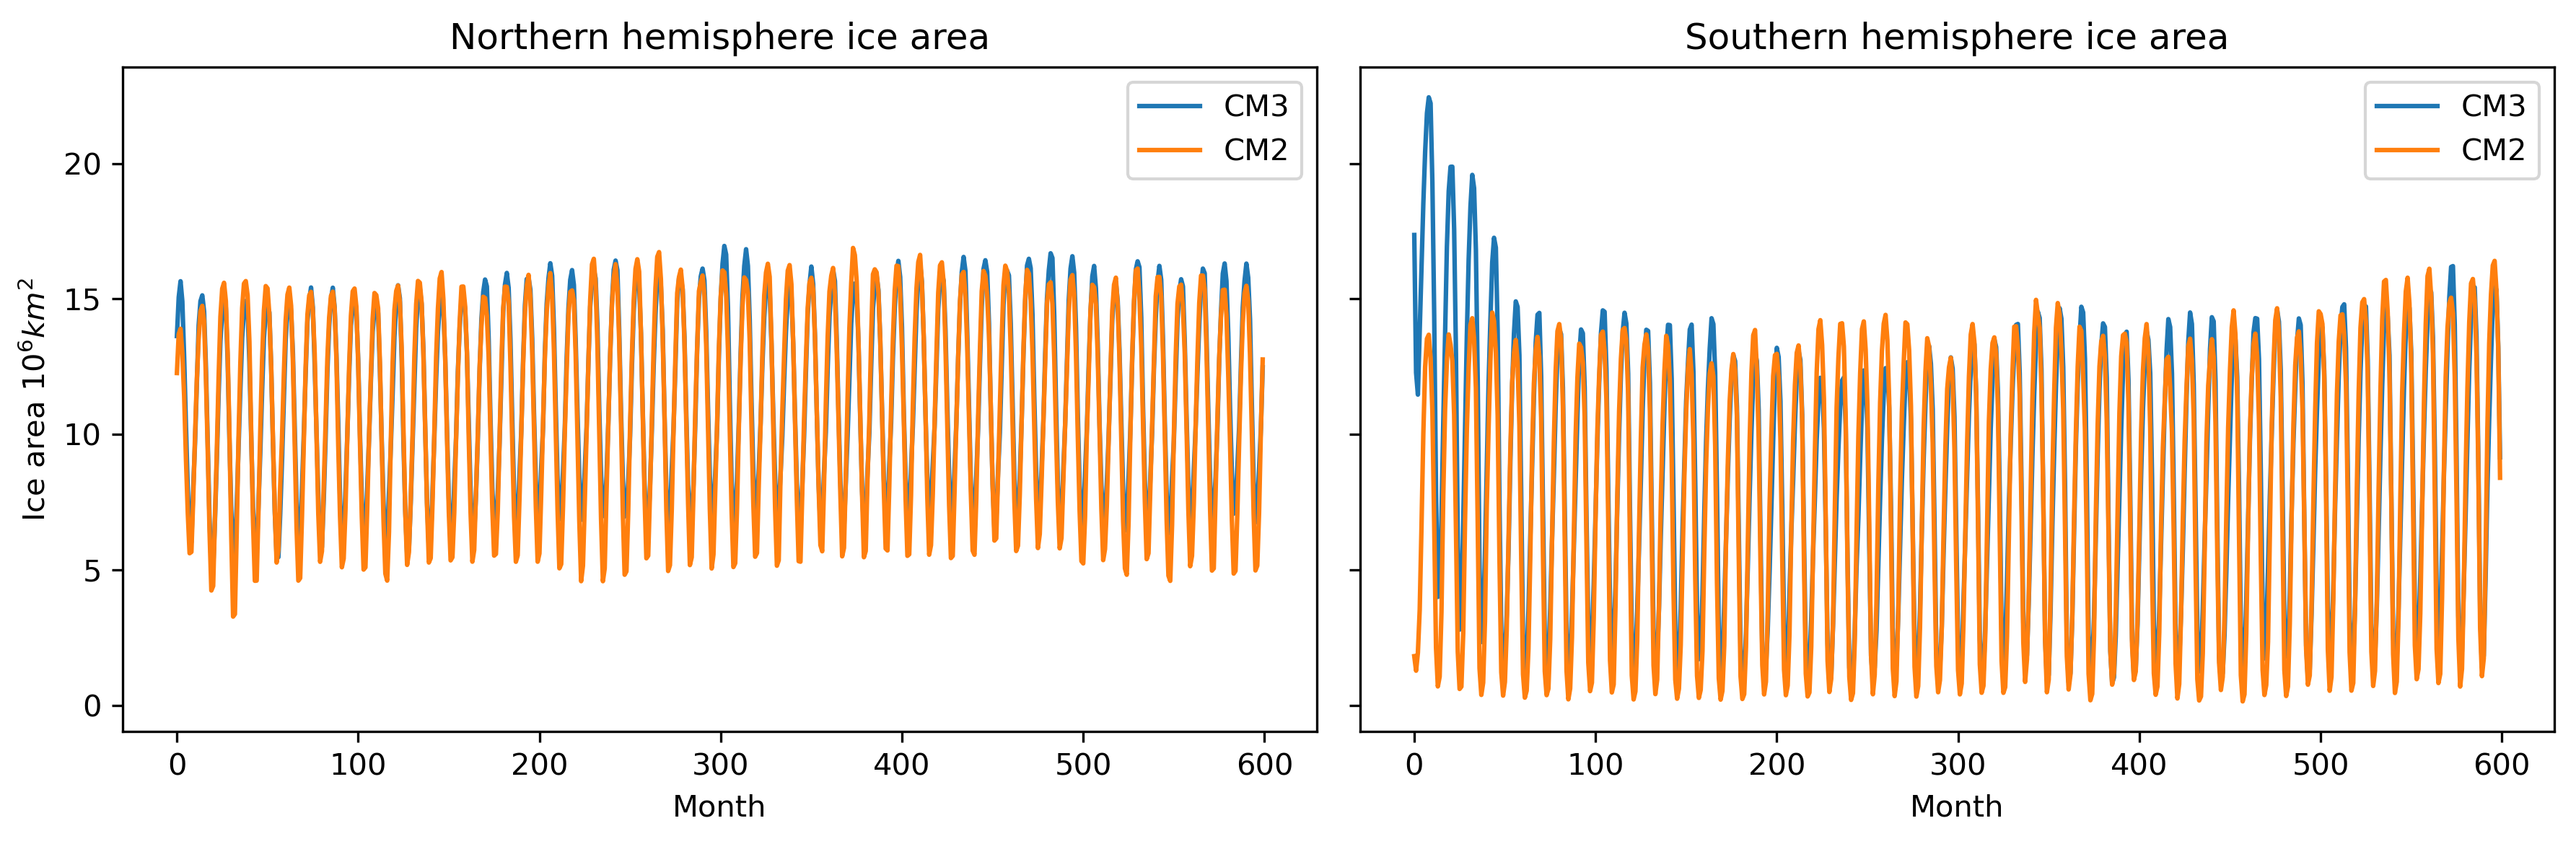

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(cm3_nh_ice_area / 1e12, label='CM3')
ax1.plot(cm2_nh_ice_area / 1e12, label='CM2')
ax2.plot(cm3_sh_ice_area / 1e12, label='CM3')
ax2.plot(cm2_sh_ice_area / 1e12, label='CM2')

ax1.set_title('Northern hemisphere ice area')
ax1.set_ylabel('Ice area $10^6 km^2$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice area')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()

## Ice volume

### Load CM3 data

In [33]:
%%time
cm3_nh_ice_vol = cm3_ice_ds.vicen_m.weighted(cm3_nh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

CPU times: user 32.3 s, sys: 2.83 s, total: 35.2 s
Wall time: 4min 37s


In [34]:
%%time
cm3_sh_ice_vol = cm3_ice_ds.vicen_m.weighted(cm3_sh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

CPU times: user 25.1 s, sys: 1.35 s, total: 26.4 s
Wall time: 2min 6s


### Load CM2 data

In [24]:
cm2_vice = xr.DataArray(da.concatenate([ds.vicen.data for ds in cm2_cice_ds_list]), dims=('time', 'nc', 'nj', 'ni'))

In [25]:
%%time
cm2_nh_ice_vol = cm2_vice.weighted(cm2_nh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

2025-11-05 16:08:02,754 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 3.15 GiB -- Worker memory limit: 4.50 GiB
2025-11-05 16:08:15,239 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:44783
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104

CPU times: user 27.8 s, sys: 2.54 s, total: 30.4 s
Wall time: 3min 45s


In [26]:
%%time
cm2_sh_ice_vol = cm2_vice.weighted(cm2_sh_mask).sum(dim=('nc', 'nj', 'ni')).compute()

2025-11-05 16:12:02,608 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 3.14 GiB -- Worker memory limit: 4.50 GiB


CPU times: user 26.4 s, sys: 2.41 s, total: 28.9 s
Wall time: 3min 18s


### Plot

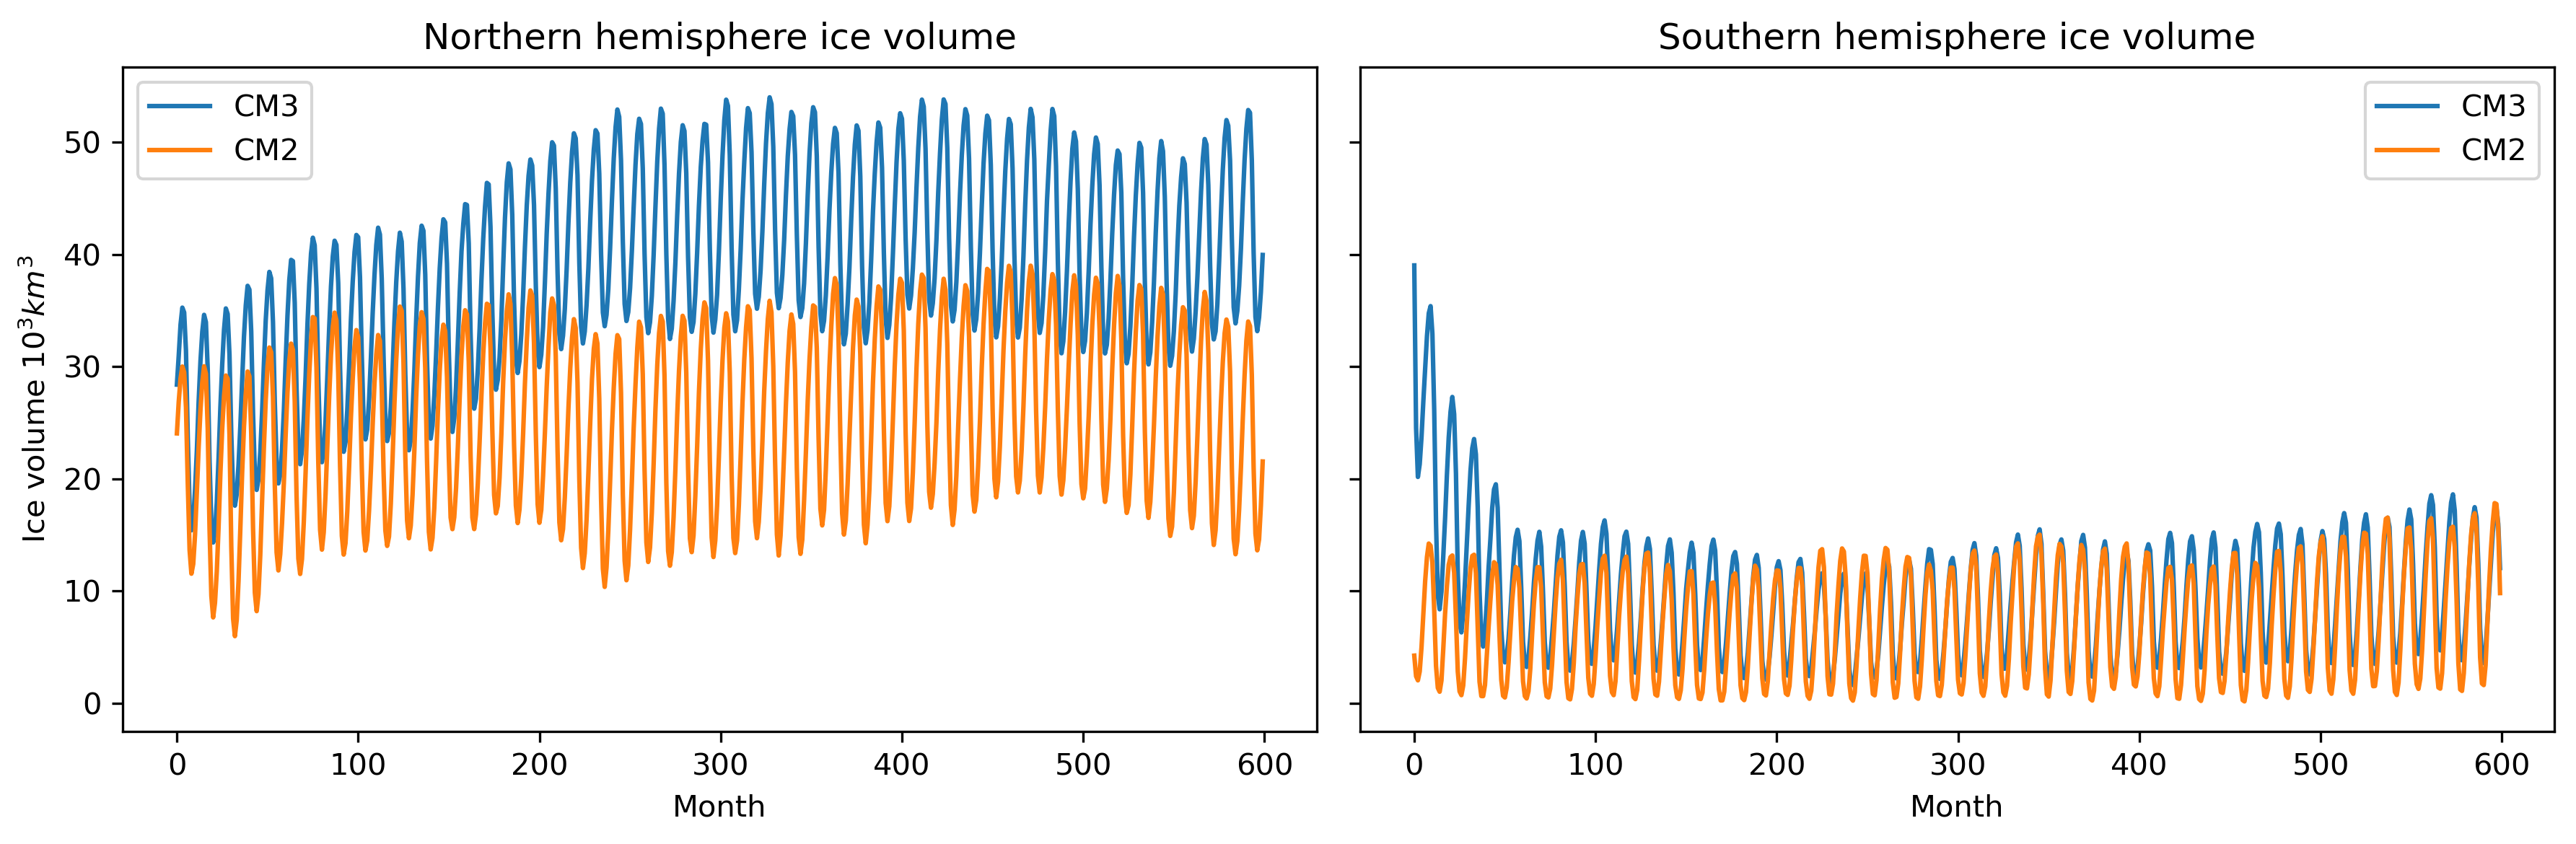

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.plot(cm3_nh_ice_vol / 1e12, label='CM3')
ax1.plot(cm2_nh_ice_vol / 1e12, label='CM2')
ax2.plot(cm3_sh_ice_vol / 1e12, label='CM3')
ax2.plot(cm2_sh_ice_vol / 1e12, label='CM2')

ax1.set_title('Northern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax1.set_xlabel('Month')
ax1.legend()

ax2.set_title('Southern hemisphere ice volume')
ax1.set_ylabel('Ice volume $10^3 km^3$')
ax2.set_xlabel('Month')
ax2.legend()
plt.tight_layout()

# Atmosphere time series

In [21]:
# fn = "atmos.1day.bnds:2.depth:4.lat:144.lat_v:145.lon:192.lon_u:192.model_rho_level_number:52.model_theta_level_number:52.pseudo_level:9.json"
fn = "atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json"
fp = os.path.join(os.path.split(esm_file)[0], 'virtualised_outputs', fn)
atm_ds = xr.open_dataset(fp, engine="kerchunk")


INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_o

In [27]:
toa = atm_ds.fld_s01i207 - atm_ds.fld_s01i208 - atm_ds.fld_s02i205

In [28]:
avg_toa = toa.weighted(areacella).mean(dim=('lat', 'lon')).compute()

INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_outputs/atmos.1mon.bnds:2.depth:4.lat:144.lat_river:180.lat_v:145.lon:192.lon_river:360.lon_u:192.model_rho_level_number:85.model_theta_level_number:85.model_theta_level_number_0:50.model_theta_level_number_2:52.pressure:17.pseudo_level:6.pseudo_level_0:5.ps.json
INFO:fsspec.reference:Read reference from URL /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/virtualised_o

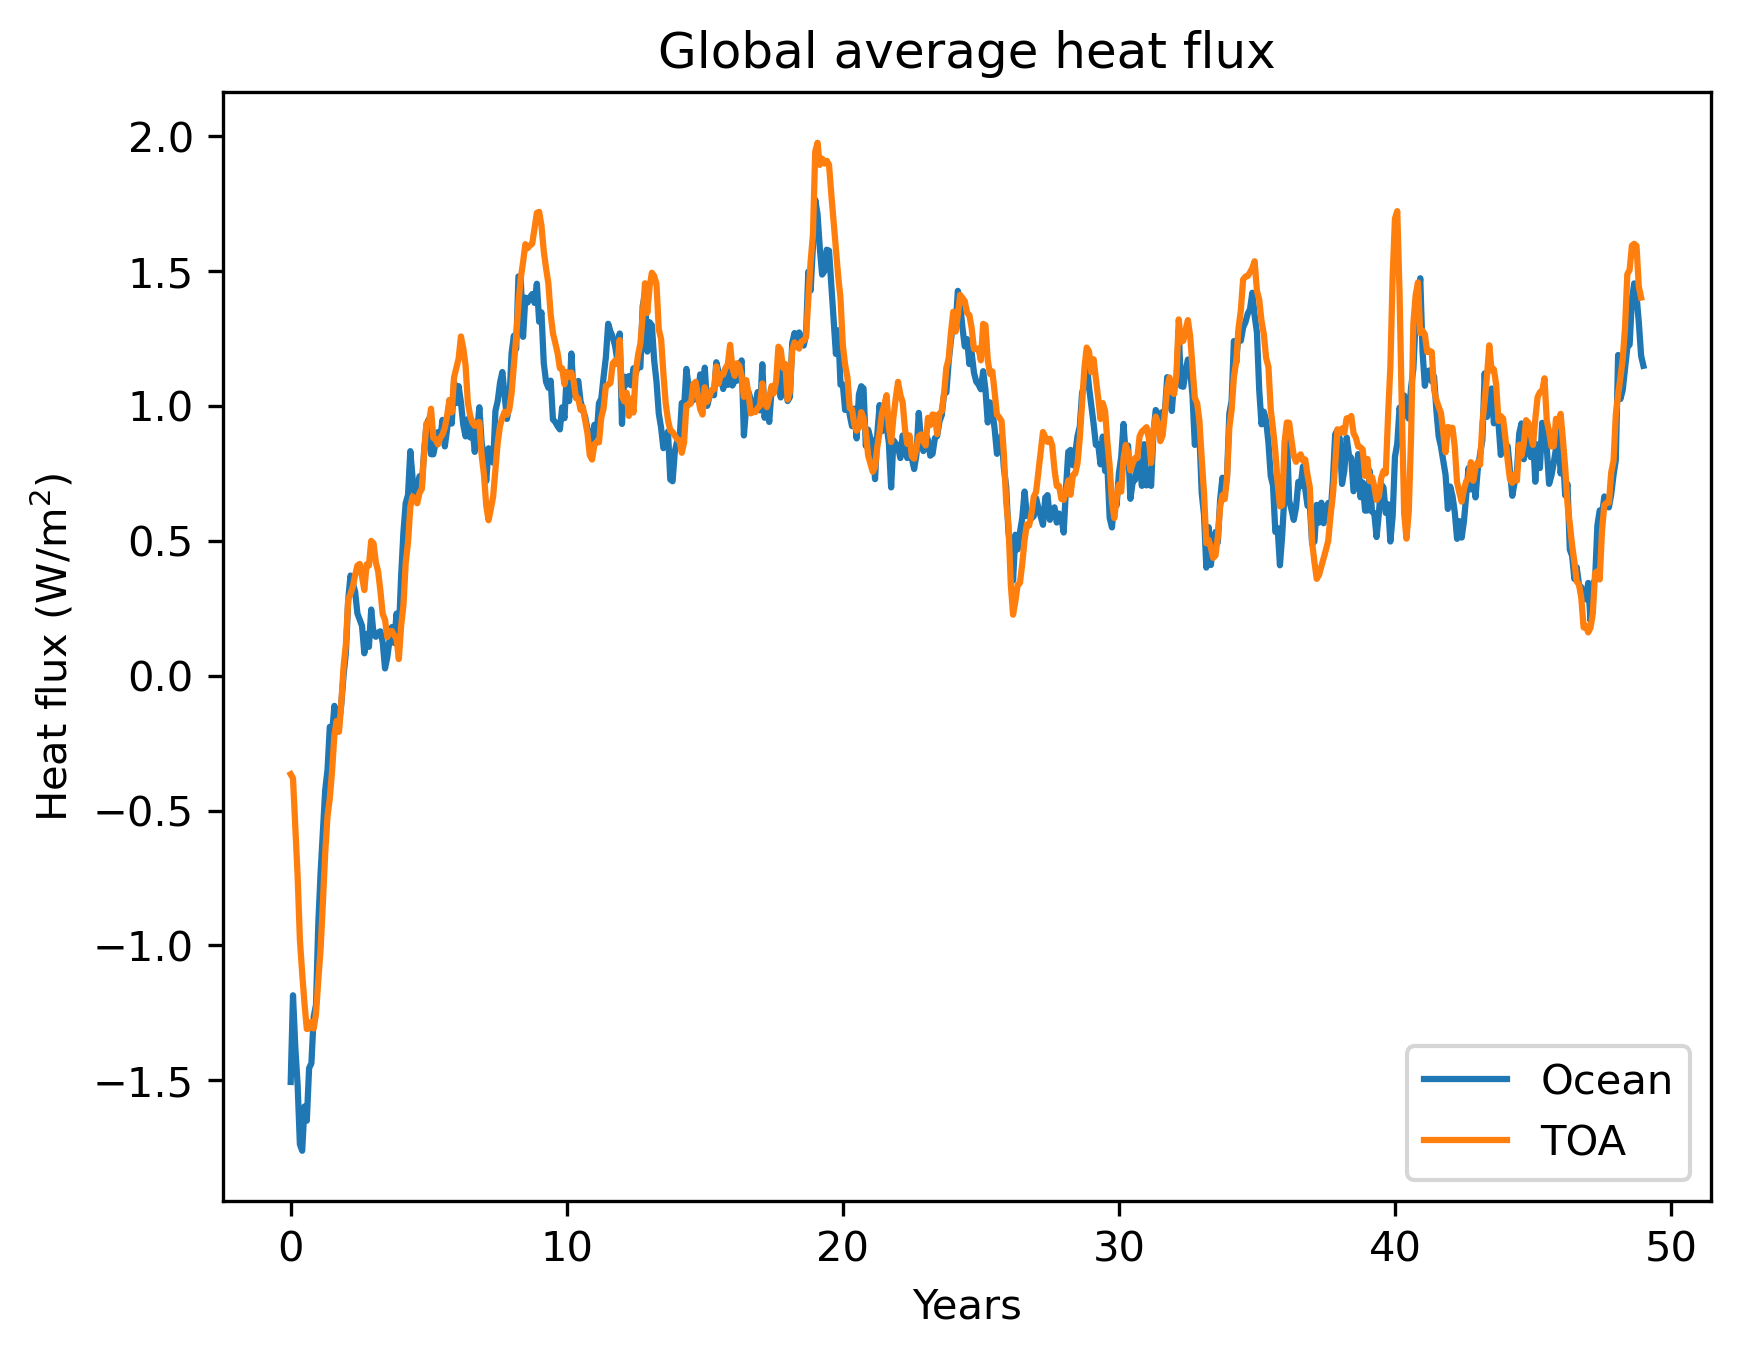

In [29]:
N = 12

rolling_avg = np.convolve(cm3_avg_ocean_heatflux, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='Ocean')

rolling_avg = np.convolve(avg_toa, np.ones(N) / N, mode='valid')
plt.plot(np.arange(len(rolling_avg)) / 12, rolling_avg, label='TOA')

plt.title('Global average heat flux')

plt.ylabel('Heat flux (W/m$^2$)')
plt.xlabel('Years')
plt.legend()